<a href="https://colab.research.google.com/github/JhonHendricksBautista/CPE313_Bautista-Jhon/blob/main/Hands_On_Activity_7_1_%7C_CNN_Architectures%2C_Regularization_and_Transfer_Learning_GRP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On-Activity 7.1
Names: Bautista, Jhon Hendricks <br>
Bulambao, Adrian Justin
<br>
Section: CPE32S4 <br>
Date: 03/23/2026 <br>
Instructor: Engr. Neal Barton James Matira

# DATASET
https://www.kaggle.com/datasets/techsash/waste-classification-data

This dataset is for performing image classification on the trash

# Procedure

Perform Training and Validation using the following techniques:

1. CNN

2. CNN with Regularization

3. Transfer Learning (feature transfer )

4. Transfer Learning (fine-tuning)

Plot the accuracy for every 10 epochs for both Training and Validation.

Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity)

Plot the ROC AUC score result of the model

Interpret and evaluate the result of the model.

Include a conclusion/summary of the activity.

Submit a PDF of the IPYNB and an accessible link.

## Loading Dataset

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path
train_dir = r"waste\TRAIN"
test_dir  = r"waste\TEST"

img_height, img_width = 256, 256
batch_size = 8
val_split = 0.2


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# TRAIN
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# VALIDATION
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# TEST
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Info
print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 18052 images belonging to 2 classes.
Found 4512 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Classes: {'O': 0, 'R': 1}
Train samples: 18052
Validation samples: 4512
Test samples: 2513


### Here in the first code block we first loaded the dataset through the proper pathing and then perform a data split. Since the raw directory of the dataset does not have validation set, we coded a splitting in which we extract 20 % of the training into the validation. For the initial data loader we have no augmentations for now.

## 1. CNN

In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

inputs = Input(shape=(img_height, img_width, 3))
x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)


x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(1, activation='sigmoid')(x)

# Model
model = Model(inputs=inputs, outputs=outputs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 128, 128, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 64)      18496     
                                                                 
 conv2d_2 (Conv2D)           (None, 128, 128, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 64, 64, 64)       0         
 2D)                                                         

### We use early stopping so that we can controll the training time and conserve compute units

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
ballers1 = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    batch_size= 8,
    callbacks=[early_stop]
)

Epoch 1/100
2257/2257 [==============================] - 198s 31ms/step - loss: 0.4673 - accuracy: 0.7947 - val_loss: 0.4868 - val_accuracy: 0.7906
Epoch 2/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3941 - accuracy: 0.8353 - val_loss: 0.3776 - val_accuracy: 0.8378
Epoch 3/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3642 - accuracy: 0.8509 - val_loss: 0.3601 - val_accuracy: 0.8391
Epoch 4/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3508 - accuracy: 0.8585 - val_loss: 0.3457 - val_accuracy: 0.8455
Epoch 5/100
2257/2257 [==============================] - 69s 30ms/step - loss: 0.3332 - accuracy: 0.8679 - val_loss: 0.3210 - val_accuracy: 0.8639
Epoch 6/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3202 - accuracy: 0.8746 - val_loss: 0.3188 - val_accuracy: 0.8721
Epoch 7/100
2257/2257 [==============================] - 68s 30ms/step - loss: 0.3113 - accuracy: 0.8773 - val_loss: 

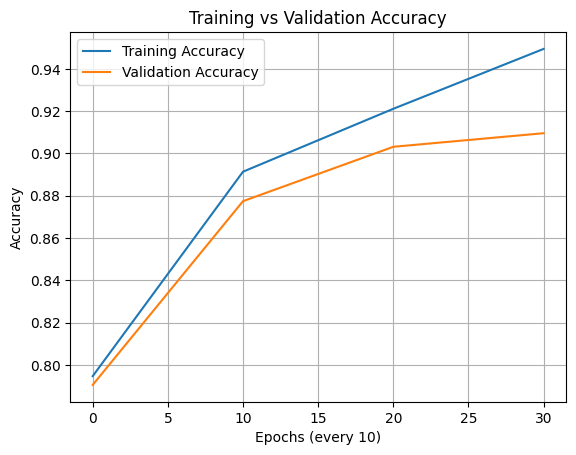

In [ ]:
import matplotlib.pyplot as plt

acc = ballers1.history['accuracy']
val_acc = ballers1.history['val_accuracy']

epochs = range(1, len(acc) + 1)

# Get every 10th epoch
epoch_ticks = list(range(0, len(epochs), 10))

plt.figure()
plt.plot(epoch_ticks, [acc[i] for i in epoch_ticks], label='Training Accuracy')
plt.plot(epoch_ticks, [val_acc[i] for i in epoch_ticks], label='Validation Accuracy')

plt.xlabel('Epochs (every 10)')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

### The model overfits based on the figure output above because the accuracy of the model on the validation is not going up in further epochs while the training accuracy keeps climbing.

In [ ]:
import numpy as np

# Get predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

315/315 [==============================] - 3s 8ms/step


ROC-AUC

315/315 [==============================] - 2s 8ms/step


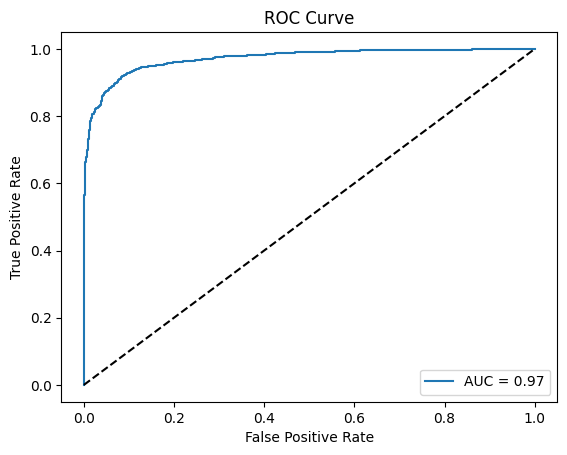

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_probs = model.predict(test_generator).ravel()
y_true = test_generator.classes

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Based on the figure above the model can reliably identify the difference of the two classes. This tells that the model have decent performance in calssifying the two classes

CONFUSION MATRIX

In [ ]:
class_labels = list(test_generator.class_indices.keys())

In [ ]:
y_pred_probs = model.predict(test_generator).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

315/315 [==============================] - 2s 7ms/step


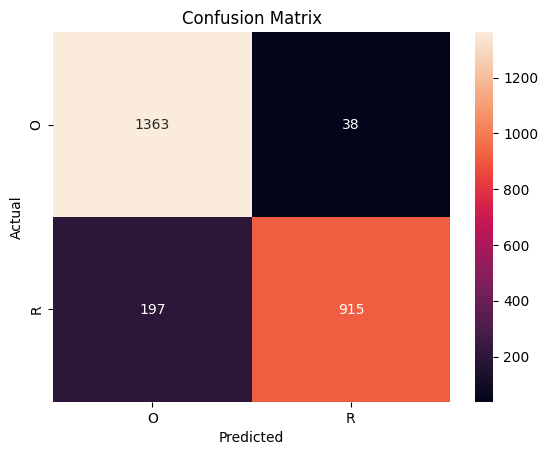

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### In the confusion matrix of the model we can see that the model has many correct predictions for both the organic and recycable images however we can see that the model has slight bias on the organic class since there we many false predictions on this class.

CLASSIFICATION REPORT

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           O       0.87      0.97      0.92      1401
           R       0.96      0.82      0.89      1112

    accuracy                           0.91      2513
   macro avg       0.92      0.90      0.90      2513
weighted avg       0.91      0.91      0.91      2513



### Here in the classification report we can observe that the model has good accuracy since it reached 91% however the imbalance of the two classes precision and recall tells us that the model needs more tuning so that it can have better generalization.

## 2. CNN with Regularization (WITH AUGMENTATION)

### We created a new dataloader wherein we implement some data augmentation to help the model in better generalization on the two classes.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = r"waste\TRAIN"
test_dir  = r"waste\TEST"

img_height, img_width = 256, 256
batch_size = 16
val_split = 0.2

# TRAIN
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split,

    rotation_range=40,
    width_shift_range=0.4,
    height_shift_range=0.4,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 2.0],
    channel_shift_range=20.0,
    fill_mode='nearest'
)

# TEST
test_datagen = ImageDataGenerator(rescale=1./255)

# TRAIN
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# VALIDATION
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# TEST
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Info
print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 18052 images belonging to 2 classes.
Found 4512 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Classes: {'O': 0, 'R': 1}
Train samples: 18052
Validation samples: 4512
Test samples: 2513


### Here I used l2 penalty, batch normalization and dropouts in order to have regularization on each of the blocks for the model. I used this since this is one of the common regularization techniques for models.

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Input
inputs = Input(shape=(img_height, img_width, 3))

x = Conv2D(32, (3,3), activation='relu', padding='same',
           kernel_regularizer=l2(0.0001))(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=l2(0.0001))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=l2(0.0001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(1, activation='sigmoid')(x)
model2 = Model(inputs=inputs, outputs=outputs)

model2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model2.summary()

Model: "model_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 256, 256, 3)]     0         
                                                                 
 conv2d_94 (Conv2D)          (None, 256, 256, 32)      896       
                                                                 
 batch_normalization_72 (Bat  (None, 256, 256, 32)     128       
 chNormalization)                                                
                                                                 
 max_pooling2d_60 (MaxPoolin  (None, 128, 128, 32)     0         
 g2D)                                                            
                                                                 
 conv2d_95 (Conv2D)          (None, 128, 128, 64)      18496     
                                                                 
 conv2d_96 (Conv2D)          (None, 128, 128, 64)      369

In [ ]:
ballers2 = model2.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    batch_size= 16,
    callbacks=[early_stop]
)


Epoch 1/100
1129/1129 [==============================] - 317s 280ms/step - loss: 0.5228 - accuracy: 0.7716 - val_loss: 0.4689 - val_accuracy: 0.7932
Epoch 2/100
1129/1129 [==============================] - 237s 210ms/step - loss: 0.4673 - accuracy: 0.7961 - val_loss: 0.4524 - val_accuracy: 0.8072
Epoch 3/100
1129/1129 [==============================] - 171s 151ms/step - loss: 0.4340 - accuracy: 0.8154 - val_loss: 0.4263 - val_accuracy: 0.8047
Epoch 4/100
1129/1129 [==============================] - 166s 147ms/step - loss: 0.4277 - accuracy: 0.8176 - val_loss: 0.4456 - val_accuracy: 0.8149
Epoch 5/100
1129/1129 [==============================] - 165s 146ms/step - loss: 0.4151 - accuracy: 0.8248 - val_loss: 0.4705 - val_accuracy: 0.7861
Epoch 6/100
1129/1129 [==============================] - 166s 147ms/step - loss: 0.4081 - accuracy: 0.8297 - val_loss: 0.5499 - val_accuracy: 0.7493
Epoch 7/100
1129/1129 [==============================] - 165s 146ms/step - loss: 0.4051 - accuracy: 0.8318

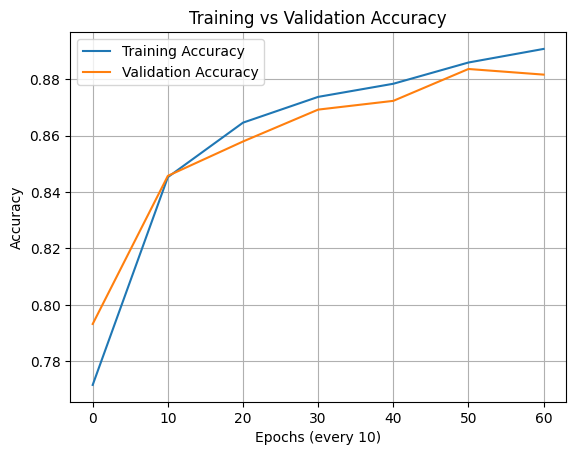

In [ ]:
import matplotlib.pyplot as plt

acc = ballers2.history['accuracy']
val_acc = ballers2.history['val_accuracy']

epochs = range(1, len(acc) + 1)

# Get every 10th epoch
epoch_ticks = list(range(0, len(epochs), 10))

plt.figure()
plt.plot(epoch_ticks, [acc[i] for i in epoch_ticks], label='Training Accuracy')
plt.plot(epoch_ticks, [val_acc[i] for i in epoch_ticks], label='Validation Accuracy')

plt.xlabel('Epochs (every 10)')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

### Based on the figure above the model now have good accuracy progeression even if the accuracy was reduced. This shows that the model has lessened the case of overfitting since there is only a small difference in the valdiation and training accuracy however the performance still needs improvement.

ROC-AUC

158/158 [==============================] - 3s 17ms/step


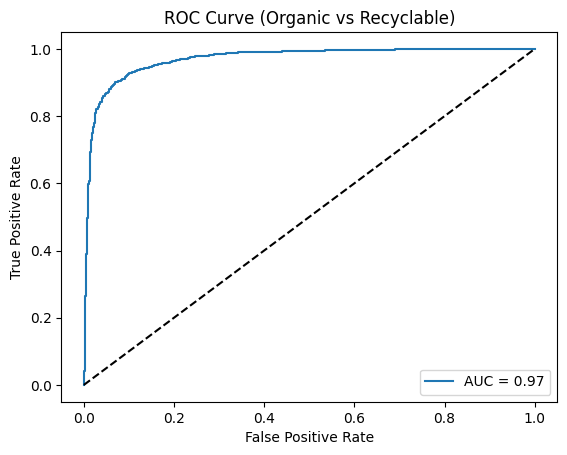

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_probs = model2.predict(test_generator).ravel()
y_true = test_generator.classes

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Organic vs Recyclable)")
plt.legend()
plt.show()

### This shows that the model still has good performance on classifying the two classes.

CONFUSION MATRIX

In [ ]:
y_pred_probs = model2.predict(test_generator).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

158/158 [==============================] - 3s 17ms/step


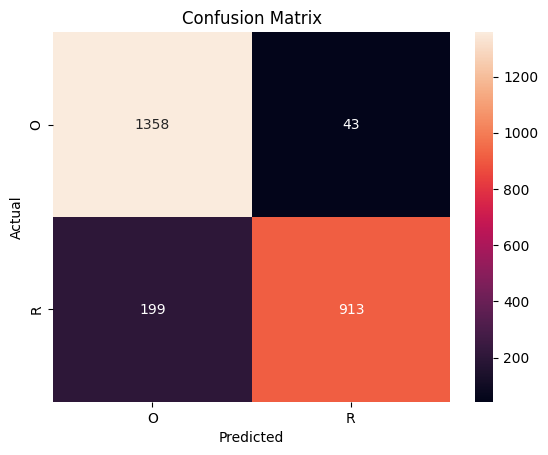

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### In the confusion matrix its shows that the model still has the same problem as before in which if has a bias on the organic class.

CLASSIFICATION REPORT

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           O       0.87      0.97      0.92      1401
           R       0.96      0.82      0.88      1112

    accuracy                           0.90      2513
   macro avg       0.91      0.90      0.90      2513
weighted avg       0.91      0.90      0.90      2513



### In the classification report we observe that the issue is still the same in which the model still has imbalance precision and recall on the two classes. With that we think that the model can have some more tuning or regularization which can help boost the performance. Also other augmentation options can be explore in order to improve the models generalization.

# INCEPTION V3

## 3. Transfer Learning (feature transfer )

Here we used another dataloade since we neede resize the images to the proper input shape of the inception model

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path
train_dir = r"waste\TRAIN"
test_dir  = r"waste\TEST"

img_height, img_width = 299, 299
batch_size = 8
val_split = 0.2


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# TRAIN
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# VALIDATION
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# TEST
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Info
print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 18052 images belonging to 2 classes.
Found 4512 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Classes: {'O': 0, 'R': 1}
Train samples: 18052
Validation samples: 4512
Test samples: 2513


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

inputs = Input(shape=(img_height, img_width, 3))
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_tensor=inputs
)
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(1, activation='sigmoid')(x)
model3 = Model(inputs=inputs, outputs=outputs)

model3.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_94 (Conv2D)             (None, 149, 149, 32  864         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_94 (BatchN  (None, 149, 149, 32  96         ['conv2d_94[0][0]']              
 ormalization)                  )                                                             

In [ ]:
res = model3.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    batch_size= 8,
    callbacks = [early_stop]
)

Epoch 1/100
2257/2257 [==============================] - 92s 39ms/step - loss: 0.2314 - accuracy: 0.9089 - val_loss: 0.1634 - val_accuracy: 0.9346
Epoch 2/100
2257/2257 [==============================] - 91s 40ms/step - loss: 0.1716 - accuracy: 0.9339 - val_loss: 0.1392 - val_accuracy: 0.9501
Epoch 3/100
2257/2257 [==============================] - 94s 41ms/step - loss: 0.1532 - accuracy: 0.9424 - val_loss: 0.1373 - val_accuracy: 0.9501
Epoch 4/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.1427 - accuracy: 0.9463 - val_loss: 0.1431 - val_accuracy: 0.9477
Epoch 5/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.1266 - accuracy: 0.9518 - val_loss: 0.1457 - val_accuracy: 0.9515
Epoch 6/100
2257/2257 [==============================] - 92s 41ms/step - loss: 0.1188 - accuracy: 0.9560 - val_loss: 0.1424 - val_accuracy: 0.9506
Epoch 7/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.1113 - accuracy: 0.9579 - val_loss: 0

ACCURACY PLOT

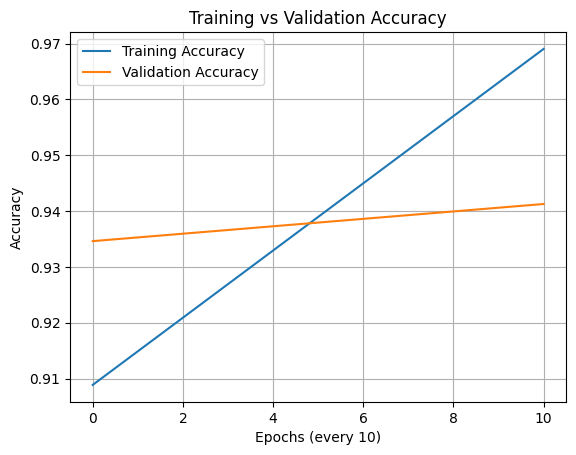

In [ ]:
import matplotlib.pyplot as plt

acc = res.history['accuracy']
val_acc = res.history['val_accuracy']

epochs = range(1, len(acc) + 1)

# Get every 10th epoch
epoch_ticks = list(range(0, len(epochs), 10))

plt.figure()
plt.plot(epoch_ticks, [acc[i] for i in epoch_ticks], label='Training Accuracy')
plt.plot(epoch_ticks, [val_acc[i] for i in epoch_ticks], label='Validation Accuracy')

plt.xlabel('Epochs (every 10)')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

### Based on the figure above the accuracy of the inception model started off very good compared to the CNN model. Then as the model trains it shows the signs of overfitting since the accuracy of the training and validation has a huge gap. However it is to note that the validation accuracy is better than the CNN model.

ROC-AUC

315/315 [==============================] - 10s 29ms/step


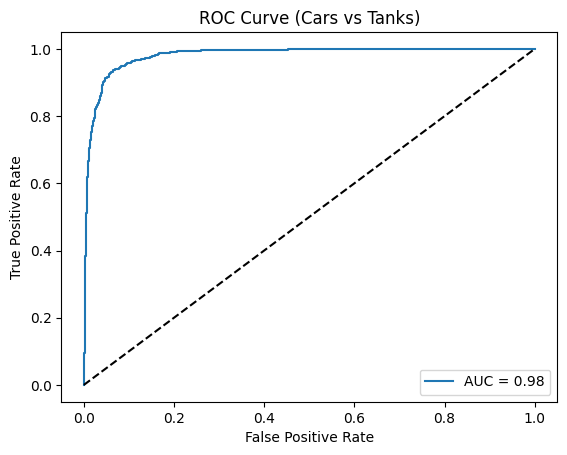

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_probs = model3.predict(test_generator).ravel()
y_true = test_generator.classes

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Organic Vs Recyclable")
plt.legend()
plt.show()

### In in the ROC curve plot show that the model has a great performance in identifying the two classes. since the curve almost hugs the top left the model already has good performance.

CONFUSION MATRIX

In [ ]:
y_pred_probs = model3.predict(test_generator).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

315/315 [==============================] - 9s 28ms/step


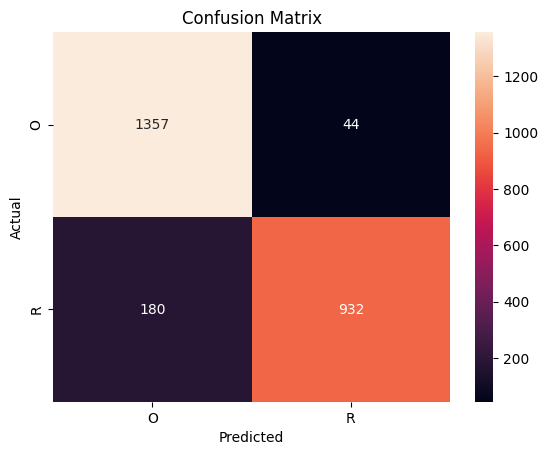

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
class_labels = list(test_generator.class_indices.keys())

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### In the confusion matrix we see that the model predicted most of the test set correctly and has slightly better performance compared to the CNN model. However it still shows the bias on th organic class.

CLASSIFICATION REPORT

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           O       0.88      0.97      0.92      1401
           R       0.95      0.84      0.89      1112

    accuracy                           0.91      2513
   macro avg       0.92      0.90      0.91      2513
weighted avg       0.91      0.91      0.91      2513



### Based on the classification report the model has greater aaccuracy and performance than the CNN model. In here we see that in the two classes there is still a slight imbalance of their precision and recall which means there is still some improvement we can do.

## 4. Transfer Learning (fine-tuning)

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model4 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


model4.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model4.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 8, 8, 2048)        21802784  
                                                                 
 global_average_pooling2d_5   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_9 (Dense)             (None, 128)               262272    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_10 (Dense)            (None, 1)                 129       
                                                                 
Total params: 22,065,185
Trainable params: 7,435,713
Non-trainable params: 14,629,472
__________________________________

In [ ]:
res2 = model4.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    batch_size= 64,
    callbacks = [early_stop]
)

Epoch 1/100
2257/2257 [==============================] - 92s 40ms/step - loss: 0.2085 - accuracy: 0.9207 - val_loss: 0.1261 - val_accuracy: 0.9508
Epoch 2/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.1235 - accuracy: 0.9550 - val_loss: 0.1993 - val_accuracy: 0.9260
Epoch 3/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0757 - accuracy: 0.9762 - val_loss: 0.2698 - val_accuracy: 0.9153
Epoch 4/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0550 - accuracy: 0.9820 - val_loss: 0.1812 - val_accuracy: 0.9515
Epoch 5/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0438 - accuracy: 0.9857 - val_loss: 0.2042 - val_accuracy: 0.9441
Epoch 6/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0340 - accuracy: 0.9904 - val_loss: 0.2921 - val_accuracy: 0.9227
Epoch 7/100
2257/2257 [==============================] - 88s 39ms/step - loss: 0.0277 - accuracy: 0.9915 - val_loss: 0

ACCURACY PLOT

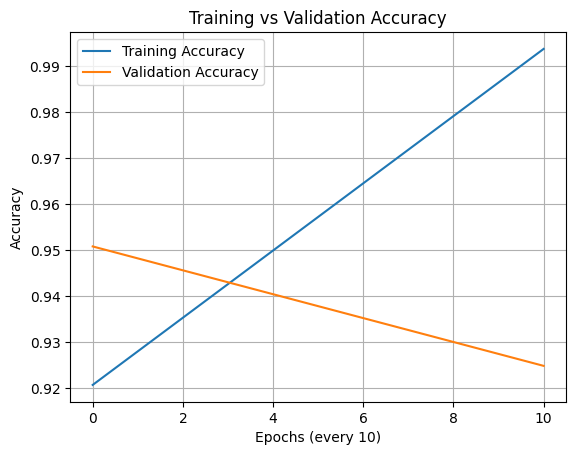

In [ ]:
import matplotlib.pyplot as plt

acc = res2.history['accuracy']
val_acc = res2.history['val_accuracy']

epochs = range(1, len(acc) + 1)

# Get every 10th epoch
epoch_ticks = list(range(0, len(epochs), 10))

plt.figure()
plt.plot(epoch_ticks, [acc[i] for i in epoch_ticks], label='Training Accuracy')
plt.plot(epoch_ticks, [val_acc[i] for i in epoch_ticks], label='Validation Accuracy')

plt.xlabel('Epochs (every 10)')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

### Based on this plot the initial weights of the model has better accuracy than by the end of training since the accuracy of the validation. I think the low learning rate causing minor weight adjustments hindered the performance of the model as training goes and caused it to overfit. Also since model is relatively big, the number of layers being trained affected the overfitting of the model.

ROC-AUC

315/315 [==============================] - 9s 26ms/step


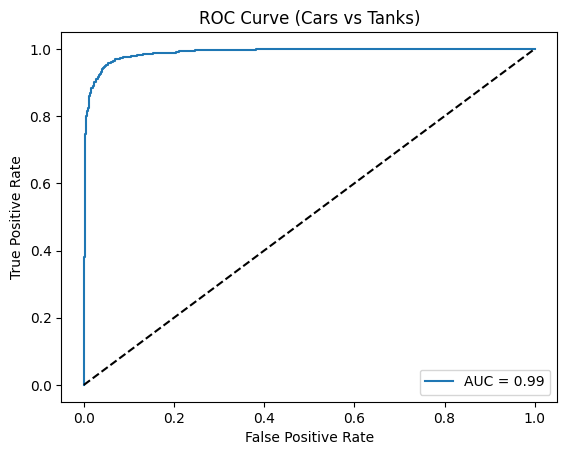

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Get probabilities (flatten to 1D)
y_pred_probs = model4.predict(test_generator).ravel()

# True labels
y_true = test_generator.classes

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Organic VS Recyclable")
plt.legend()
plt.show()

### Based on the ROC plot output the model has a slight improvement since the AUC socre is 0.99. The model retains its great performance in having a high true positive rating.

CONFUSION MATRIX

In [ ]:
y_pred_probs = model4.predict(test_generator).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

315/315 [==============================] - 8s 26ms/step


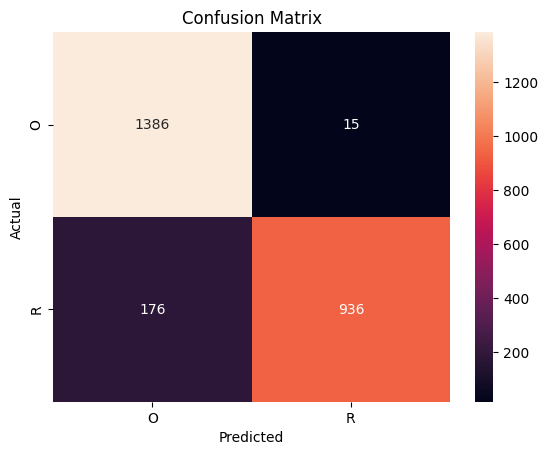

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Based on the output of the confusion matrix the model has now better predictions since it has now lessen the false negatives and false positives even if a little percent. This shows the slight improvement or fine tuning of the model can help.

CLASSIFICATION REPORT

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           O       0.89      0.99      0.94      1401
           R       0.98      0.84      0.91      1112

    accuracy                           0.92      2513
   macro avg       0.94      0.92      0.92      2513
weighted avg       0.93      0.92      0.92      2513



### In the classification report it shows the the model improved its accuracy to 92% and now the two classes have a better f1 score. This tells us that there is now better generalization of the model between the two classes and the fine tuning of the model greatly helped.

# CONCLUSION

After performing this activity we were able to demonstrate the usage of CNN models and pretrained models in performing image classification. For this activity we were able to create CNN models from scratch and implement data augmentation and regularization techniques to improve its performance and compare it to transfer learning on a pretrained model. We were able to compare their performance through different visualizations of accuracy plots, ROC curve and classification reports. By the end, we observed that the pretrained and fine tuning of the model has the best performance of all since it was able to improve its accuracy and have a better balance on the precisio and recall for the two classes though it did not reach 95% accuracy requirement its performance is still good. With that we see that proper data management and augmentation can address the models lacking in performance. We think that a better image dataset and proper augmentation the model can have better generalization and reach 95% accuracy